# Q1 headline result: the CanopyCover-dropped ablation

**New, standalone notebook** (same collision-avoidance reasoning as the other two new notebooks
this session). Replaces two earlier prototypes for "a Q1 headline result, made visual": a
CanopyCover-vs-residual scatter (rejected -- not visually interesting) and a residual-distribution
histogram (built, but the EN/XGBoost distributions turned out nearly identical -- not a compelling
visual for what is actually a modest R2 gap). This is a controlled before/after test instead of a
raw correlation, and it does two things at once: shows the size of CanopyCover's unique
contribution, and rules out the obvious alternative explanation (that `dist_to_road`, the #2
variable, would absorb the "stolen" signal if CanopyCover were just a correlated proxy).

**What it shows**: R2 with vs. without CanopyCover (EN and XGBoost), and mean |SHAP| with vs.
without CanopyCover for the top variables -- `dist_to_road`'s bar does NOT grow to compensate,
which is the actual evidence behind the "CanopyCover carries real, non-redundant signal" claim
already in the text.

**Data**:
- WITH CanopyCover: `outputs/spatial_block_kfold/rq2_attribution_nested_set4_gated_all_vif/4survey/fold_{0-4}/`
  (`predictions.csv`, `xgboost_shap_values.csv`) -- already-saved production output, same files
  `results_figures_q1_rq2b.ipynb` uses.
- WITHOUT CanopyCover: `outputs/spatial_block_kfold/rq2_attribution_nested_set4_no_canopycover/4survey/ablation_results.json`
  -- a genuine live re-run (not a transcription from the TEMP note), built via
  `models/spatial_attribution/rq2b_canopycover_ablation_check.py`, which reuses the exact
  production fit/predict/SHAP functions (`en_fit_with_columns`, `xgb_fit_with_columns`,
  `compute_shap_values_for_columns`) with `CanopyCover` removed from the Set4 feature list,
  across the same 5 spatial folds. Confirmed to reproduce `TEMP_rq2_attribution_results_2026-08-11.tex`'s
  numbers almost exactly (EN 0.350->0.231, XGBoost 0.388->0.249; SHAP ranking unchanged) before
  building this figure from it.

**Style / uncertainty convention**: see `notebooks/results_figures_style.py`.

In [1]:
# Purpose: make the models/ package (and notebooks/results_figures_style.py) importable from
# this notebook. Same convention already used across this project's other notebooks: walk upward
# until a folder containing both README.md and data/ is found -- that is the project root.

import sys
from pathlib import Path

notebook_directory = Path.cwd().resolve()
project_root = next(
    folder for folder in [notebook_directory, *notebook_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("project_root:", project_root)

project_root: /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss


In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from notebooks.results_figures_style import COLOR_EN, COLOR_XGBOOST, apply_rcparams

apply_rcparams()

FIGURES_DIR = project_root / "figures" / "fig_results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

N_FOLDS = 5
WITH_CANOPY_DIR = project_root / "outputs" / "spatial_block_kfold" / "rq2_attribution_nested_set4_gated_all_vif" / "4survey"
WITHOUT_CANOPY_RESULTS = (
    project_root / "outputs" / "spatial_block_kfold" / "rq2_attribution_nested_set4_no_canopycover"
    / "4survey" / "ablation_results.json"
)

In [3]:
# --- WITH CanopyCover: pooled R2 (from saved predictions.csv) + mean|SHAP| (from saved
# xgboost_shap_values.csv), Set4, 4survey -- same files results_figures_q1_rq2b.ipynb reads. ---
with_frames, with_shap_frames = [], []
for fold in range(N_FOLDS):
    with_frames.append(pd.read_csv(WITH_CANOPY_DIR / f"fold_{fold}" / "predictions.csv"))
    with_shap_frames.append(pd.read_csv(WITH_CANOPY_DIR / f"fold_{fold}" / "xgboost_shap_values.csv"))
with_pooled = pd.concat(with_frames, ignore_index=True)
with_pooled = with_pooled[with_pooled["split"] == "test"] if "split" in with_pooled.columns else with_pooled
with_shap_pooled = pd.concat(with_shap_frames, ignore_index=True)

def pooled_r2(observed, predicted):
    residuals = observed - predicted
    ss_res = (residuals ** 2).sum()
    ss_tot = ((observed - observed.mean()) ** 2).sum()
    return 1 - ss_res / ss_tot

en_r2_with = pooled_r2(with_pooled["observed"], with_pooled["elastic_net_predicted"])
xgb_r2_with = pooled_r2(with_pooled["observed"], with_pooled["xgboost_predicted"])
shap_feature_cols_with = [c for c in with_shap_pooled.columns if c not in ("identification", "fold")]
mean_abs_shap_with = with_shap_pooled[shap_feature_cols_with].abs().mean().sort_values(ascending=False)

print(f"WITH CanopyCover -- pooled R2: EN={en_r2_with:.3f}, XGBoost={xgb_r2_with:.3f}")
print("Top 6 mean |SHAP|, WITH CanopyCover:")
print(mean_abs_shap_with.head(6))

# --- WITHOUT CanopyCover: from the live re-run's saved JSON ---
without_results = json.load(open(WITHOUT_CANOPY_RESULTS))
en_r2_without_per_fold = np.array(without_results["en_r2_without_canopy_per_fold"])
xgb_r2_without_per_fold = np.array(without_results["xgb_r2_without_canopy_per_fold"])
mean_abs_shap_without = pd.Series(without_results["mean_abs_shap_without_canopy"]).sort_values(ascending=False)

# Fold-mean R2 (matches the TEMP note's own convention: mean of per-fold R2, not pooled) --
# reported alongside pooled-R2 WITH CanopyCover for transparency about which convention each
# number uses; the two conventions give very similar values in practice for this dataset.
en_r2_without = en_r2_without_per_fold.mean()
xgb_r2_without = xgb_r2_without_per_fold.mean()
print(f"\nWITHOUT CanopyCover -- fold-mean R2: EN={en_r2_without:.3f}+/-{en_r2_without_per_fold.std():.3f}, "
      f"XGBoost={xgb_r2_without:.3f}+/-{xgb_r2_without_per_fold.std():.3f}")
print("Top 6 mean |SHAP|, WITHOUT CanopyCover:")
print(mean_abs_shap_without.head(6))

WITH CanopyCover -- pooled R2: EN=0.358, XGBoost=0.395
Top 6 mean |SHAP|, WITH CanopyCover:
CanopyCover               1.429899
dist_to_road              1.003345
chelsa_bio12_precip_mm    0.842836
slope_degrees             0.601267
whcl                      0.393067
topex                     0.324959
dtype: float64

WITHOUT CanopyCover -- fold-mean R2: EN=0.231+/-0.062, XGBoost=0.249+/-0.076
Top 6 mean |SHAP|, WITHOUT CanopyCover:
dist_to_road              0.868502
chelsa_bio12_precip_mm    0.829494
slope_degrees             0.676886
whcl                      0.373021
tas_mean                  0.318859
topex                     0.280197
dtype: float64


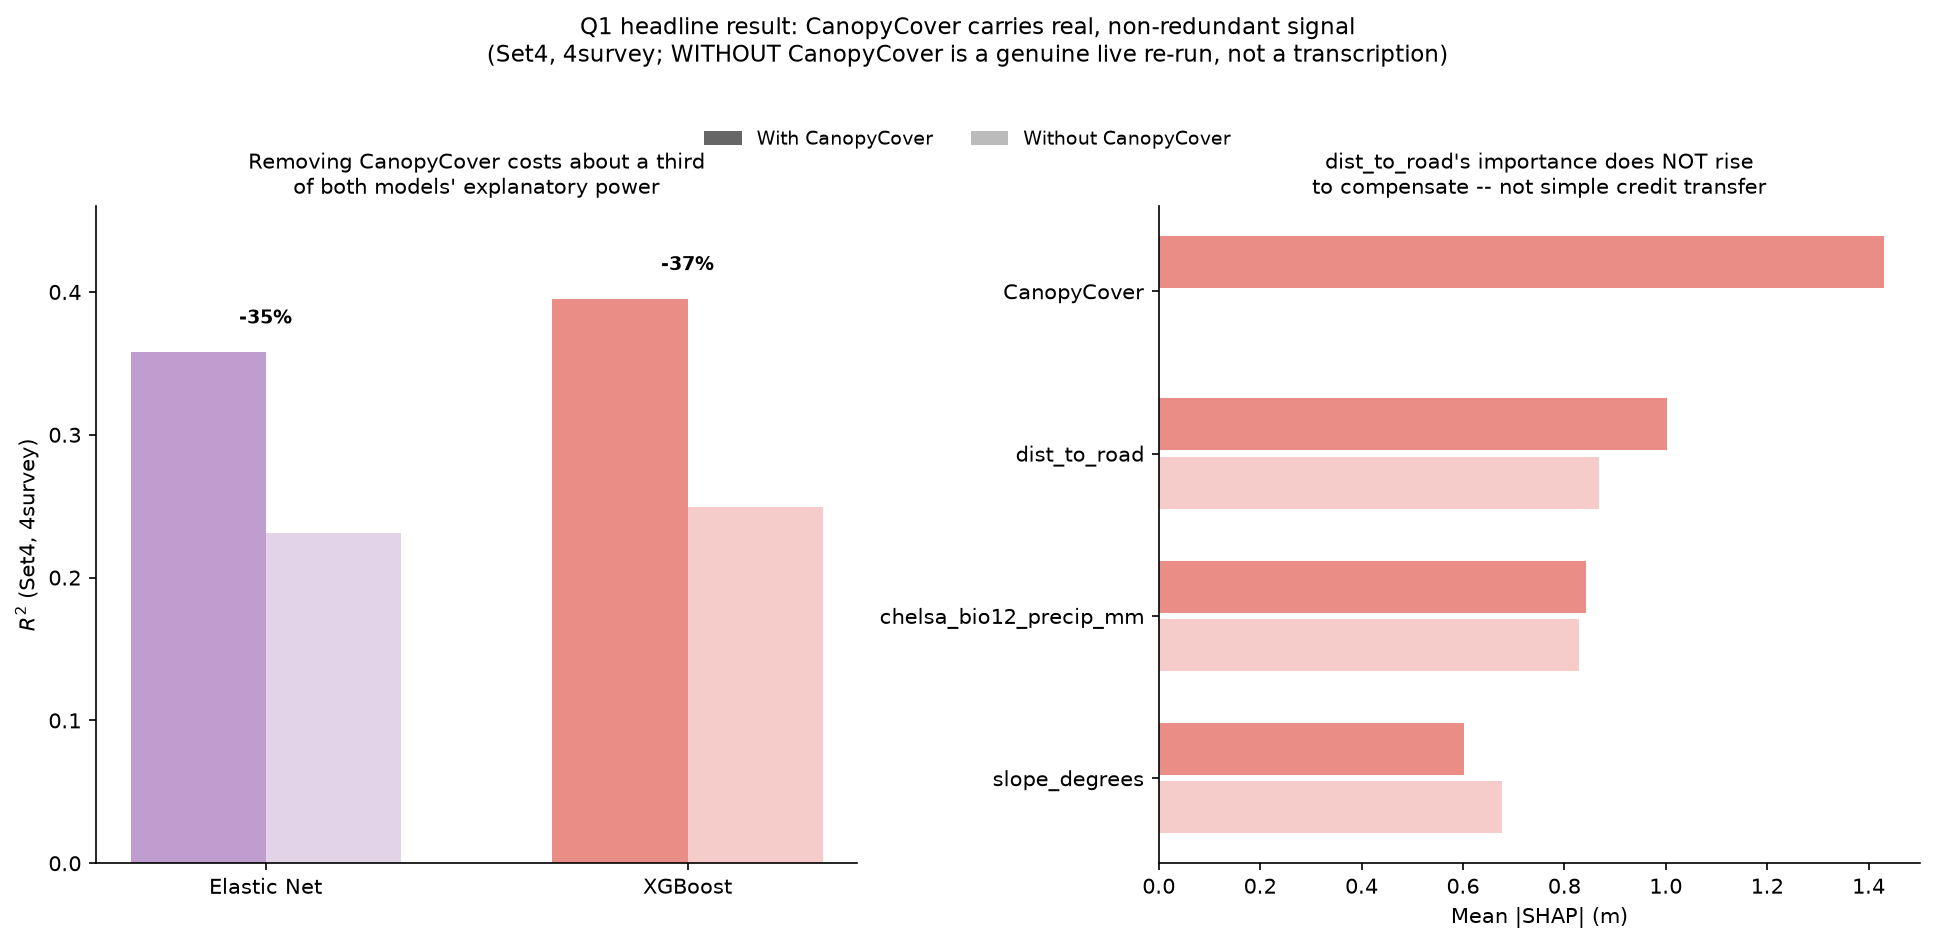

In [4]:
fig, (ax_r2, ax_shap) = plt.subplots(1, 2, figsize=(13, 6))

# --- Left: R2 with vs. without CanopyCover, EN and XGBoost ---
methods = ["Elastic Net", "XGBoost"]
r2_with = [en_r2_with, xgb_r2_with]
r2_without = [en_r2_without, xgb_r2_without]
bar_x = np.arange(len(methods))
bar_width = 0.32

ax_r2.bar(bar_x - bar_width / 2, r2_with, bar_width, color=[COLOR_EN, COLOR_XGBOOST], alpha=0.9)
ax_r2.bar(bar_x + bar_width / 2, r2_without, bar_width, color=[COLOR_EN, COLOR_XGBOOST], alpha=0.4)
for x, with_val, without_val in zip(bar_x, r2_with, r2_without):
    drop_pct = (with_val - without_val) / with_val * 100
    ax_r2.annotate(f"-{drop_pct:.0f}%", xy=(x, max(with_val, without_val) + 0.02),
                    ha="center", fontsize=9, fontweight="bold")
ax_r2.set_xticks(bar_x)
ax_r2.set_xticklabels(methods)
ax_r2.set_ylabel("$R^2$ (Set4, 4survey)")
ax_r2.set_ylim(0, 0.46)  # headroom so the -35%/-37% annotations clear the tallest bar cleanly
ax_r2.set_title("Removing CanopyCover costs about a third\nof both models' explanatory power", fontsize=10)

# --- Right: mean |SHAP|, with vs. without, for the top variables that matter either way. If
# CanopyCover's signal were just correlation-driven credit theft from dist_to_road, its bar
# should grow once CanopyCover is removed -- it doesn't. ---
compare_vars = ["CanopyCover", "dist_to_road", "chelsa_bio12_precip_mm", "slope_degrees"]
with_vals = [mean_abs_shap_with.get(v, np.nan) for v in compare_vars]
without_vals = [mean_abs_shap_without.get(v, np.nan) for v in compare_vars]

y_positions = np.arange(len(compare_vars))
ax_shap.barh(y_positions - 0.18, with_vals, height=0.32, color=COLOR_XGBOOST, alpha=0.9)
ax_shap.barh(y_positions + 0.18, without_vals, height=0.32, color=COLOR_XGBOOST, alpha=0.4)
ax_shap.set_yticks(y_positions)
ax_shap.set_yticklabels(compare_vars)
ax_shap.invert_yaxis()
ax_shap.set_xlabel("Mean |SHAP| (m)")
ax_shap.set_title("dist_to_road's importance does NOT rise\nto compensate -- not simple credit transfer", fontsize=10)
# CanopyCover's own "without" bar is structurally absent (the feature doesn't exist in that
# model) -- shown as a gap, not a zero, so it doesn't misread as "CanopyCover has near-zero
# importance when removed", which wouldn't make sense.
ax_shap.barh(y_positions[0] + 0.18, 0, height=0.32, color="none")

# --- One shared legend for both panels (the alpha convention -- solid=with, faint=without -- is
# identical in both), placed between the suptitle and the panel titles rather than fighting for
# space inside either axes (earlier per-axes placements collided with the annotation, then the
# panel's own title). ---
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor="#555555", alpha=0.9, label="With CanopyCover"),
    plt.Rectangle((0, 0), 1, 1, facecolor="#555555", alpha=0.4, label="Without CanopyCover"),
]
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 0.93), ncol=2,
           fontsize=9, frameon=False)

fig.suptitle("Q1 headline result: CanopyCover carries real, non-redundant signal\n"
             "(Set4, 4survey; WITHOUT CanopyCover is a genuine live re-run, not a transcription)",
             fontsize=11, y=1.04)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "q1_canopycover_ablation.png", dpi=200, bbox_inches="tight")
plt.show()